# Q1:


## 2-1: data preparation:

### load dataset:

In [1]:
import pandas as pd
import os, sys

current_path = os.getcwd()
datset_path = os.path.join(current_path,"NNDL_HW5_S2025/data/train-00000-of-00001-982530f49cf10cee.parquet")
# Load the Parquet file::
df = pd.read_parquet(datset_path)

print(df.head(10))

                                               image  label  \
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      7   
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      7   
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      1   
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2   
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      8   
5  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      4   
6  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      5   
7  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      7   
8  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      9   
9  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      5   

                                  disease_name  
0        Tomato__Tomato_YellowLeaf__Curl_Virus  
1        Tomato__Tomato_YellowLeaf__Curl_Virus  
2  Tomato_Spider_mites_Two_spotted_spider_mite  
3                        Tomato_Bacterial_spot  
4                               Tomato_healthy  
5           

### show sample of each class:

In [2]:
import io
def decode_image(row): # a function for showing images
    return Image.open(io.BytesIO(row['image']['bytes']))

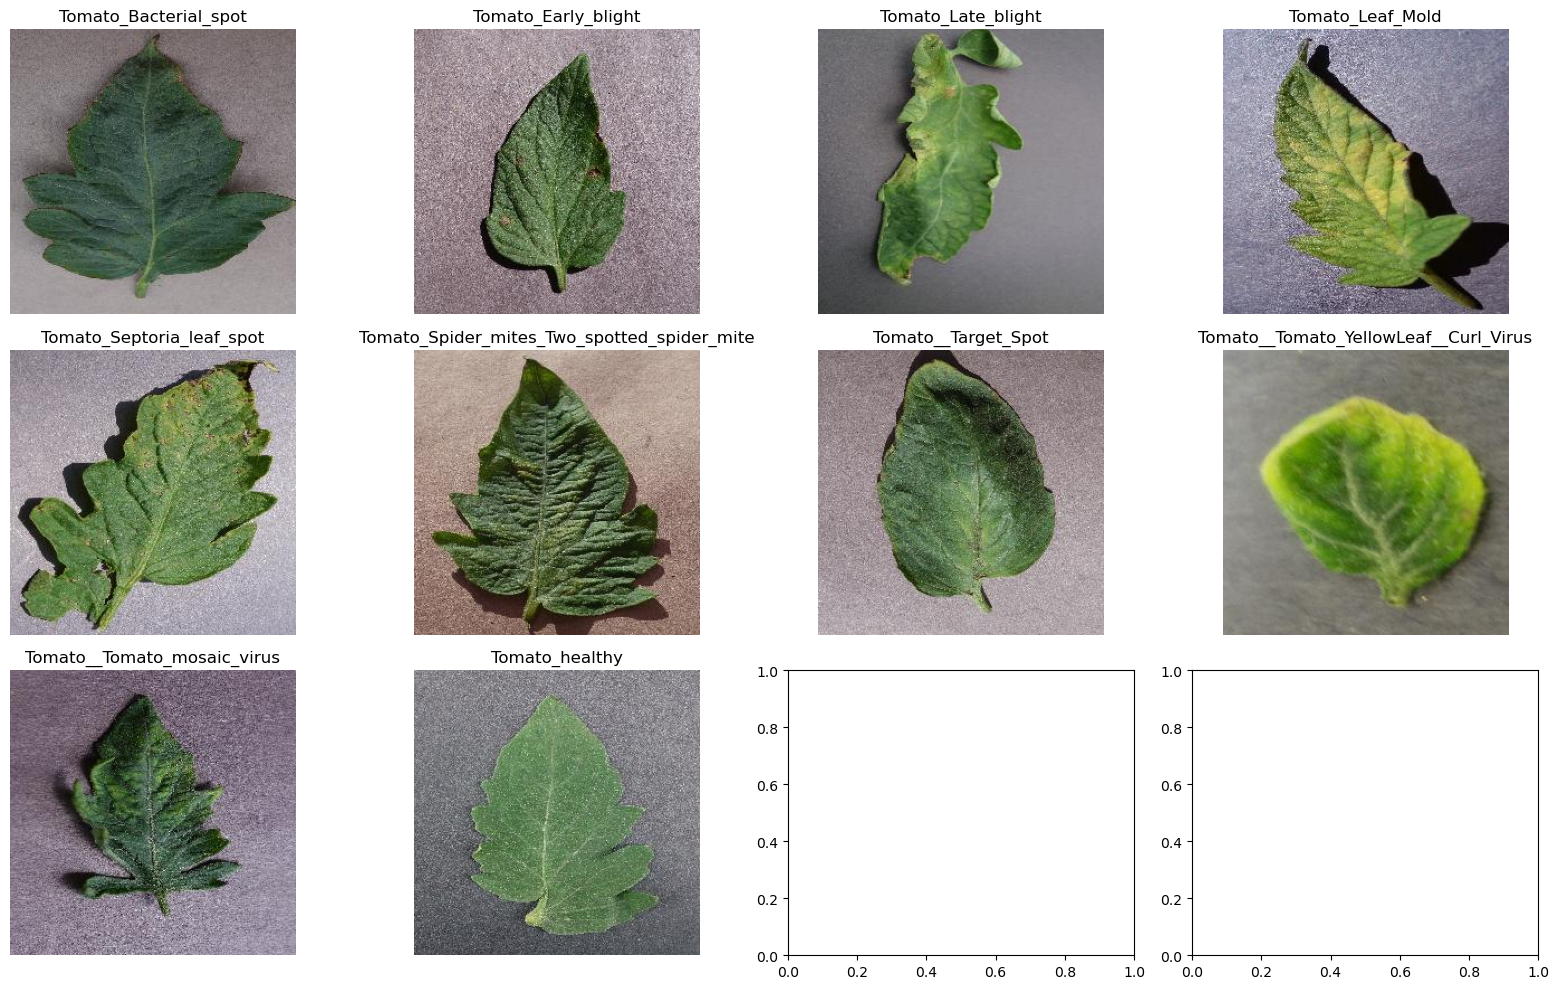

In [3]:
from PIL import Image
import io
import matplotlib.pyplot as plt



grouped_by_disease = df.groupby('disease_name') # grouping data by diseases
number_of_samples = 1

def decode_image(row): # to convert to image
    return Image.open(io.BytesIO(row['image']['bytes']))


fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
i=0
for disease, group in grouped_by_disease:

    # print(f"disease/condition is : {disease}")
    sample = group.sample(number_of_samples).iloc[0] # get samples

    img = decode_image(sample)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(disease)
    i+=1

plt.tight_layout()
plt.show()




### analyzing the dataset balance

In [4]:
label_counts = df['disease_name'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f"{label}: {count} images")

Tomato_Bacterial_spot: 1000 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1000 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1000 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1000 images
Tomato__Target_Spot: 1000 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 1000 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1000 images


### Data augmentation


In [5]:
from torchvision import transforms
from PIL import Image
import random
from tqdm import tqdm

augment_transfprm = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1,saturation=0.1)
])

needed_images = 1000

for disease in  df['disease_name'].unique():
    group = grouped_by_disease.get_group(disease)
    needed = needed_images - len(group)

    for _ in tqdm(range(needed), desc=f"Augmenting {disease}"):
        sample = group.sample(1).iloc[0]
        img = decode_image(sample)
        aug_img = augment_transfprm(img)

        buf = io.BytesIO()
        aug_img.save(buf, format='JPEG')
        byte_data = buf.getvalue()

        new_row = pd.DataFrame([{
            'image': {'bytes': byte_data},
            'label': int(sample['label']),
            'disease_name': str(sample['disease_name'])
        }])

        df = pd.concat([df, new_row], ignore_index=True)

Augmenting Tomato__Tomato_YellowLeaf__Curl_Virus: 0it [00:00, ?it/s]
Augmenting Tomato_Spider_mites_Two_spotted_spider_mite: 0it [00:00, ?it/s]
Augmenting Tomato_Bacterial_spot: 0it [00:00, ?it/s]
Augmenting Tomato_healthy: 0it [00:00, ?it/s]
Augmenting Tomato_Septoria_leaf_spot: 0it [00:00, ?it/s]
Augmenting Tomato__Tomato_mosaic_virus: 100%|██████████| 627/627 [00:01<00:00, 375.91it/s]
Augmenting Tomato_Early_blight: 0it [00:00, ?it/s]
Augmenting Tomato__Target_Spot: 0it [00:00, ?it/s]
Augmenting Tomato_Late_blight: 0it [00:00, ?it/s]


In [6]:
label_counts = df['disease_name'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f"{label}: {count} images")

Tomato_Bacterial_spot: 1000 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1000 images
Tomato_Leaf_Mold: 1000 images
Tomato_Septoria_leaf_spot: 1000 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1000 images
Tomato__Target_Spot: 1000 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 1000 images
Tomato__Tomato_mosaic_virus: 1000 images
Tomato_healthy: 1000 images


### split data and make it ready for training:

In [7]:
from torchvision import transforms

transform_inception_v3 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.5]*3, std=[0.5]*3) 
])

transform_vit = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [8]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)

In [9]:
from torch.utils.data import Dataset

class myDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = decode_image(row)
        label = row['label']
        img_tensor = self.transform(img)
        return img_tensor, label

#### datasets:

In [10]:
# inception_v3: 
train_inception_v3_dataset= myDataset(df_train, transform_inception_v3)
val_inception_v3_dataset = myDataset(df_val, transform_inception_v3)

# vit::
train_vit_dataset = myDataset(df_train, transform_vit)
val_vit_dataset = myDataset(df_val, transform_vit)

#### data loaders:

In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# Inception-V3
train_inception_v3_dataloader = DataLoader(train_inception_v3_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_inception_v3_dataloader = DataLoader(val_inception_v3_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ViT
train_vit_dataloader = DataLoader(train_vit_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_vit_dataloader = DataLoader(val_vit_dataset, batch_size=BATCH_SIZE, shuffle=False)


## 3-1:

In [12]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
import torch.nn as nn
from torchvision import models

inception_v3 = models.inception_v3(pretrained=False, aux_logits=False)
inception_v3.fc = nn.Linear(inception_v3.fc.in_features, 10) 

inception_v3 = inception_v3.to(device)

/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


In [14]:
from torchinfo import summary
summary(inception_v3)

Layer (type:depth-idx)                   Param #
Inception3                               --
├─BasicConv2d: 1-1                       --
│    └─Conv2d: 2-1                       864
│    └─BatchNorm2d: 2-2                  64
├─BasicConv2d: 1-2                       --
│    └─Conv2d: 2-3                       9,216
│    └─BatchNorm2d: 2-4                  64
├─BasicConv2d: 1-3                       --
│    └─Conv2d: 2-5                       18,432
│    └─BatchNorm2d: 2-6                  128
├─MaxPool2d: 1-4                         --
├─BasicConv2d: 1-5                       --
│    └─Conv2d: 2-7                       5,120
│    └─BatchNorm2d: 2-8                  160
├─BasicConv2d: 1-6                       --
│    └─Conv2d: 2-9                       138,240
│    └─BatchNorm2d: 2-10                 384
├─MaxPool2d: 1-7                         --
├─InceptionA: 1-8                        --
│    └─BasicConv2d: 2-11                 --
│    │    └─Conv2d: 3-1                  12,288
│   

In [15]:
import torch.optim as optim
import time
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(inception_v3.parameters(), lr=0.001)


train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 15

for epoch in range(num_epochs):
    time1 = time.time()
    inception_v3.train()
    train_loss = 0.0
    train_correct = 0
    total = 0

    for images, labels in train_inception_v3_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = inception_v3(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0) #We multiply by images.size(0)to convert it to total loss over the batch
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / total
    train_acc = train_correct / total

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)



    inception_v3.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_inception_v3_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = inception_v3(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / total_val
    val_acc = val_correct / total_val

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch number : {epoch+1}, epoch time: {time.time()-time1:.1f}s,Train Loss: {avg_train_loss:.2f}, Train Acc: {train_acc:.2f},Val Loss: {avg_val_loss:.2f}, Val Acc: {val_acc:.2f}")
    print(f"")


Epoch number : 1, epoch time: 94.1s,Train Loss: 1.02, Train Acc: 0.66,Val Loss: 1.26, Val Acc: 0.61

Epoch number : 2, epoch time: 93.9s,Train Loss: 0.56, Train Acc: 0.81,Val Loss: 0.46, Val Acc: 0.84

Epoch number : 3, epoch time: 93.7s,Train Loss: 0.44, Train Acc: 0.85,Val Loss: 0.47, Val Acc: 0.84

Epoch number : 4, epoch time: 93.7s,Train Loss: 0.34, Train Acc: 0.88,Val Loss: 0.34, Val Acc: 0.89

Epoch number : 5, epoch time: 93.9s,Train Loss: 0.29, Train Acc: 0.90,Val Loss: 0.82, Val Acc: 0.76

Epoch number : 6, epoch time: 93.9s,Train Loss: 0.25, Train Acc: 0.91,Val Loss: 0.67, Val Acc: 0.80

Epoch number : 7, epoch time: 94.1s,Train Loss: 0.24, Train Acc: 0.92,Val Loss: 0.59, Val Acc: 0.81

Epoch number : 8, epoch time: 93.9s,Train Loss: 0.18, Train Acc: 0.94,Val Loss: 0.60, Val Acc: 0.84

Epoch number : 9, epoch time: 93.9s,Train Loss: 0.22, Train Acc: 0.93,Val Loss: 0.15, Val Acc: 0.95

Epoch number : 10, epoch time: 94.0s,Train Loss: 0.17, Train Acc: 0.94,Val Loss: 0.14, Val 

#### plot accuracy and loss:

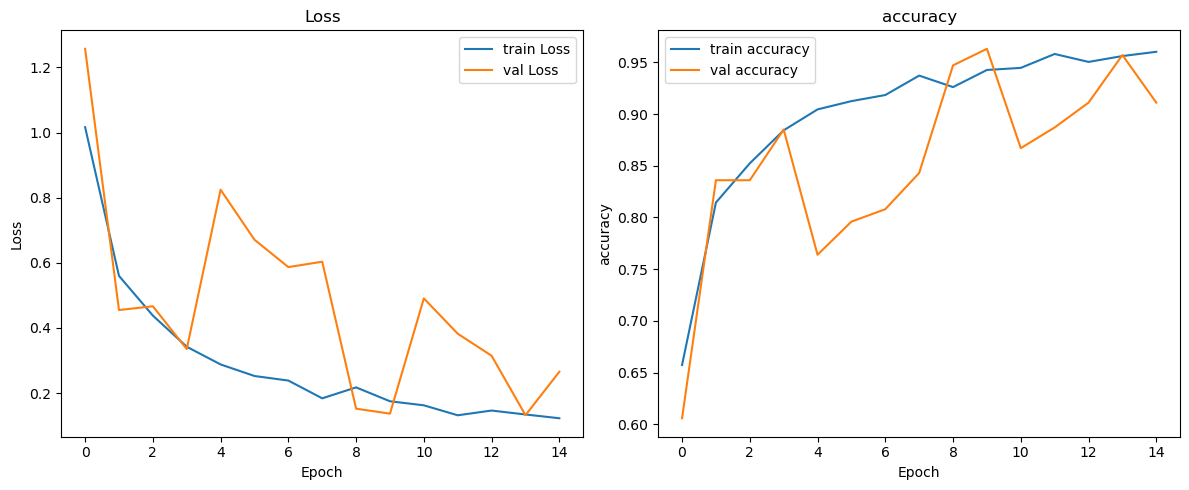

In [16]:
# loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train Loss')
plt.plot(val_losses, label='val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train accuracy')
plt.plot(val_accuracies, label='val accuracy')
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("accuracy")
plt.legend()

plt.tight_layout()
plt.show()

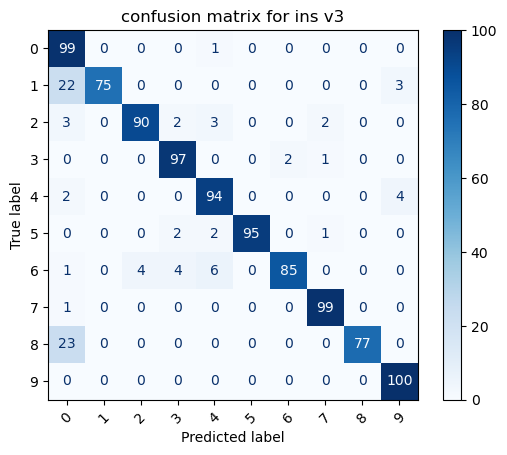

In [17]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds) # all_labels, all_preds are from the last run of the loop
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("confusion matrix for ins v3")
plt.show()

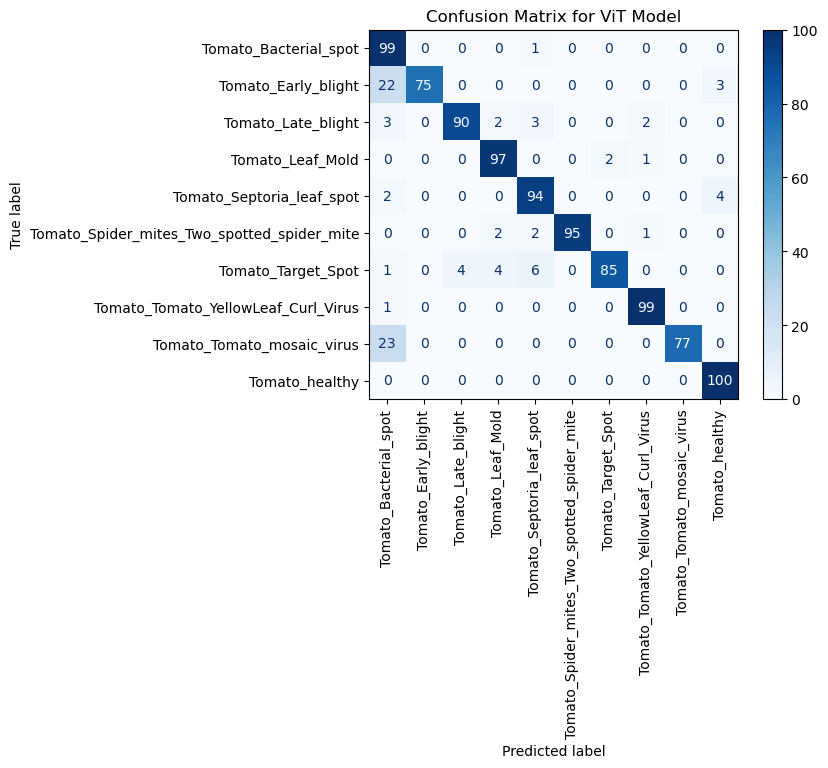

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato_Target_Spot',
    'Tomato_Tomato_YellowLeaf_Curl_Virus',
    'Tomato_Tomato_mosaic_virus',
    'Tomato_healthy'
]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix for ViT Model")
# plt.tight_layout()
plt.show()

### metrics:

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Precision: 0.9296
Recall:    0.9110
F1 Score:  0.9128


## 1-4:

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=6, emb_dim=64, num_patches=100):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.emb_dim = emb_dim

        # 6x6 patch → 108-dim → 64-dim
        self.projection = nn.Linear(108, emb_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, emb_dim))

    def forward(self, x):
        # x: [B, 3, 64, 64]
        B = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(B, 3, 10, 10, self.patch_size, self.patch_size)
        x = x.permute(0,2,3,1,4,5).contiguous().view(B, self.num_patches, -1)  # [B, 100, 108]
        x = self.projection(x)  # [B, 100, 64]
        return x + self.pos_embedding


class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_dim=64, ff_dim=128, dropout=0.35):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=2, batch_first=True)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.ff = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(ff_dim, emb_dim),
            nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x):
        
        attn_output, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_output)

        
        ff_output = self.ff(x)
        x = self.norm2(x + ff_output)
        return x

class ViTSmartAgri(nn.Module):
    def __init__(self, num_classes=10, emb_dim=64, num_patches=100, depth=8, ff_dim=128, dropout=0.35):
        super().__init__()
        self.embedding = PatchEmbedding(patch_size=6, emb_dim=64, num_patches=100)

        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(emb_dim=emb_dim, ff_dim=ff_dim, dropout=dropout)
            for _ in range(depth)
        ])
        self.flatten = nn.Flatten() 
        self.mlp_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(6400, 2048),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)          # → [B, 100, 64]
        x = self.encoder(x)            # → [B, 100, 64]
        x = self.flatten(x)            # → [B, 6400]
        return self.mlp_head(x)        # → [B, 10]




In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torchinfo import summary
vit_model = ViTSmartAgri().to(device)
summary(vit_model)

Layer (type:depth-idx)                                       Param #
ViTSmartAgri                                                 --
├─PatchEmbedding: 1-1                                        6,400
│    └─Linear: 2-1                                           6,976
├─Sequential: 1-2                                            --
│    └─TransformerEncoderBlock: 2-2                          --
│    │    └─MultiheadAttention: 3-1                          16,640
│    │    └─LayerNorm: 3-2                                   128
│    │    └─Sequential: 3-3                                  16,576
│    │    └─LayerNorm: 3-4                                   128
│    └─TransformerEncoderBlock: 2-3                          --
│    │    └─MultiheadAttention: 3-5                          16,640
│    │    └─LayerNorm: 3-6                                   128
│    │    └─Sequential: 3-7                                  16,576
│    │    └─LayerNorm: 3-8                                   128
│    └─Tr

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=0.0001, weight_decay=0.00001)
                    

num_epochs = 30  

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    time1 = time.time()
    vit_model.train()
    train_loss = 0.0
    train_correct = 0
    total = 0

    for images, labels in train_vit_dataloader:
        images, labels = images.to(device), labels.to(device)

        
        outputs = vit_model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / total
    train_acc = train_correct / total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)


    vit_model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_vit_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / total_val
    val_acc = val_correct / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}, Time: {time.time()-time1:.1f}s,Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} ,Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")




Epoch 1, Time: 10.6s,Train Loss: 2.2511, Train Acc: 0.1427 ,Val Loss: 2.1049, Val Acc: 0.2570
Epoch 2, Time: 10.4s,Train Loss: 1.9254, Train Acc: 0.2970 ,Val Loss: 1.7345, Val Acc: 0.3570
Epoch 3, Time: 10.5s,Train Loss: 1.7253, Train Acc: 0.3746 ,Val Loss: 1.4837, Val Acc: 0.4840
Epoch 4, Time: 10.5s,Train Loss: 1.4425, Train Acc: 0.4878 ,Val Loss: 1.2725, Val Acc: 0.5600
Epoch 5, Time: 10.4s,Train Loss: 1.2721, Train Acc: 0.5571 ,Val Loss: 1.1377, Val Acc: 0.6150
Epoch 6, Time: 10.4s,Train Loss: 1.1569, Train Acc: 0.5928 ,Val Loss: 0.9699, Val Acc: 0.6660
Epoch 7, Time: 10.4s,Train Loss: 1.0547, Train Acc: 0.6367 ,Val Loss: 0.9419, Val Acc: 0.6710
Epoch 8, Time: 10.4s,Train Loss: 0.9901, Train Acc: 0.6536 ,Val Loss: 0.8958, Val Acc: 0.7020
Epoch 9, Time: 10.5s,Train Loss: 0.8990, Train Acc: 0.6908 ,Val Loss: 0.8675, Val Acc: 0.7030
Epoch 10, Time: 10.5s,Train Loss: 0.8332, Train Acc: 0.7116 ,Val Loss: 0.7495, Val Acc: 0.7510
Epoch 11, Time: 10.5s,Train Loss: 0.7597, Train Acc: 0.7357

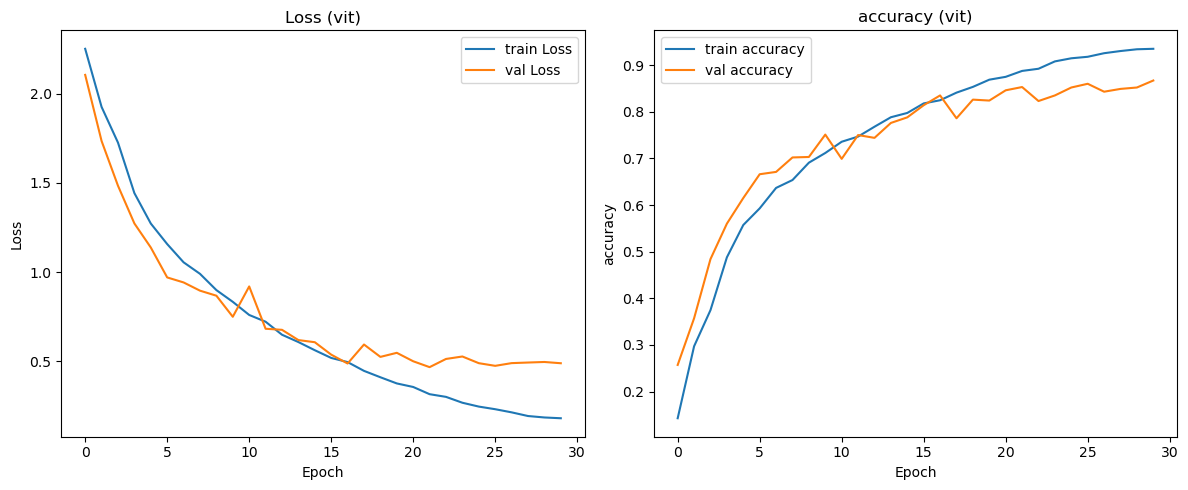

In [23]:
# loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train Loss')
plt.plot(val_losses, label='val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss (vit)")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train accuracy')
plt.plot(val_accuracies, label='val accuracy')
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("accuracy (vit)")
plt.legend()

plt.tight_layout()
plt.show()

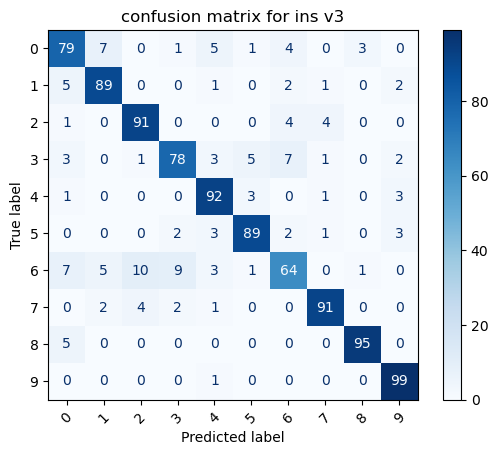

In [24]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds) # all_labels, all_preds are from the last run of the loop
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("confusion matrix for ins v3")
plt.show()

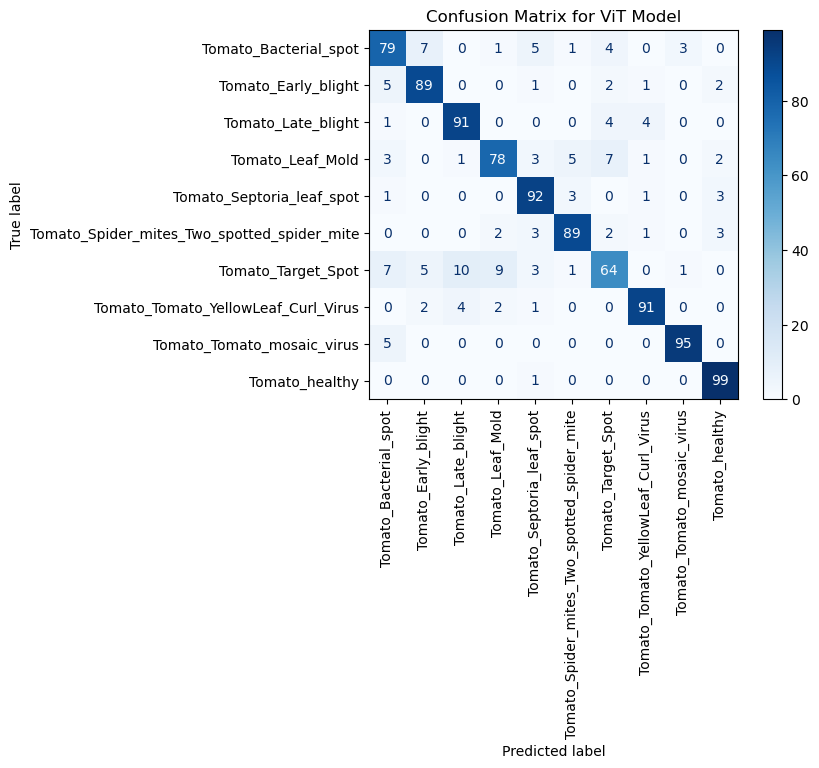

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato_Target_Spot',
    'Tomato_Tomato_YellowLeaf_Curl_Virus',
    'Tomato_Tomato_mosaic_virus',
    'Tomato_healthy'
]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=90)
# plt.figure(figsize=(12, 5))
plt.title("Confusion Matrix for ViT Model")
# plt.tight_layout()
plt.show()

### metrics:

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.8654
Recall:    0.8670
F1 Score:  0.8650


VIT with original learning rate:

In [27]:
vit_model2 = ViTSmartAgri().to(device)

import torch
import torch.nn as nn
import torch.optim as optim
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model2.parameters(), lr=0.001, weight_decay=1e-4)
                    

num_epochs = 30  

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    time1 = time.time()
    vit_model2.train()
    train_loss = 0.0
    train_correct = 0
    total = 0

    for images, labels in train_vit_dataloader:
        images, labels = images.to(device), labels.to(device)

        
        outputs = vit_model2(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / total
    train_acc = train_correct / total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)


    vit_model2.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_vit_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model2(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / total_val
    val_acc = val_correct / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}, Time: {time.time()-time1:.1f}s,Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} ,Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")




Epoch 1, Time: 11.1s,Train Loss: 2.3553, Train Acc: 0.0996 ,Val Loss: 2.3027, Val Acc: 0.1000
Epoch 2, Time: 11.8s,Train Loss: 2.3031, Train Acc: 0.0981 ,Val Loss: 2.3026, Val Acc: 0.1000
Epoch 3, Time: 11.3s,Train Loss: 2.3030, Train Acc: 0.0938 ,Val Loss: 2.3026, Val Acc: 0.1000
Epoch 4, Time: 10.7s,Train Loss: 2.3030, Train Acc: 0.0908 ,Val Loss: 2.3026, Val Acc: 0.1000
Epoch 5, Time: 10.6s,Train Loss: 2.3033, Train Acc: 0.0952 ,Val Loss: 2.3026, Val Acc: 0.1000
Epoch 6, Time: 10.6s,Train Loss: 2.3035, Train Acc: 0.0938 ,Val Loss: 2.3034, Val Acc: 0.1000
Epoch 7, Time: 10.7s,Train Loss: 2.3087, Train Acc: 0.0933 ,Val Loss: 2.3027, Val Acc: 0.1000
Epoch 8, Time: 10.6s,Train Loss: 2.3031, Train Acc: 0.0959 ,Val Loss: 2.3026, Val Acc: 0.1000
Epoch 9, Time: 10.5s,Train Loss: 2.3032, Train Acc: 0.0958 ,Val Loss: 2.3026, Val Acc: 0.1000
Epoch 10, Time: 10.6s,Train Loss: 2.3035, Train Acc: 0.0936 ,Val Loss: 2.3033, Val Acc: 0.1000
Epoch 11, Time: 10.6s,Train Loss: 2.3050, Train Acc: 0.0954

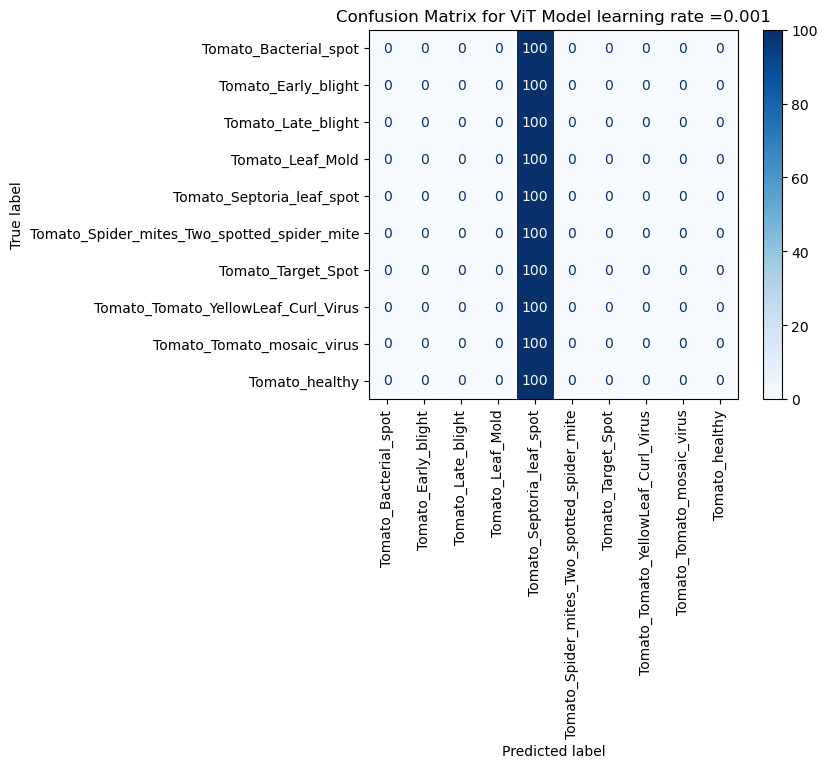

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato_Target_Spot',
    'Tomato_Tomato_YellowLeaf_Curl_Virus',
    'Tomato_Tomato_mosaic_virus',
    'Tomato_healthy'
]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=90)
# plt.figure(figsize=(12, 5))
plt.title("Confusion Matrix for ViT Model learning rate =0.001")
# plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.0100
Recall:    0.1000
F1 Score:  0.0182


/home/ali/anaconda3/envs/poseEstimation310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Vit with dropout = 0.1

In [33]:
vit_model3 = ViTSmartAgri(dropout=0.1).to(device)

import torch
import torch.nn as nn
import torch.optim as optim
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model3.parameters(), lr=0.0001, weight_decay=0.00001)
                    

num_epochs = 30  

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    time1 = time.time()
    vit_model3.train()
    train_loss = 0.0
    train_correct = 0
    total = 0

    for images, labels in train_vit_dataloader:
        images, labels = images.to(device), labels.to(device)

        
        outputs = vit_model3(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / total
    train_acc = train_correct / total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)


    vit_model3.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_vit_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model3(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / total_val
    val_acc = val_correct / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}, Time: {time.time()-time1:.1f}s,Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} ,Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1, Time: 11.0s,Train Loss: 2.0759, Train Acc: 0.2300 ,Val Loss: 1.5232, Val Acc: 0.4830
Epoch 2, Time: 10.7s,Train Loss: 1.3657, Train Acc: 0.5254 ,Val Loss: 1.1181, Val Acc: 0.6090
Epoch 3, Time: 10.7s,Train Loss: 1.1207, Train Acc: 0.6093 ,Val Loss: 0.9442, Val Acc: 0.6720
Epoch 4, Time: 10.7s,Train Loss: 0.9685, Train Acc: 0.6598 ,Val Loss: 0.9026, Val Acc: 0.6860
Epoch 5, Time: 10.7s,Train Loss: 0.8351, Train Acc: 0.7080 ,Val Loss: 0.8430, Val Acc: 0.7160
Epoch 6, Time: 10.7s,Train Loss: 0.7632, Train Acc: 0.7350 ,Val Loss: 0.7106, Val Acc: 0.7530
Epoch 7, Time: 10.6s,Train Loss: 0.6792, Train Acc: 0.7603 ,Val Loss: 0.7583, Val Acc: 0.7290
Epoch 8, Time: 10.6s,Train Loss: 0.6084, Train Acc: 0.7834 ,Val Loss: 0.6124, Val Acc: 0.7740
Epoch 9, Time: 10.7s,Train Loss: 0.5369, Train Acc: 0.8110 ,Val Loss: 0.6353, Val Acc: 0.7690
Epoch 10, Time: 10.7s,Train Loss: 0.4988, Train Acc: 0.8253 ,Val Loss: 0.5737, Val Acc: 0.8020
Epoch 11, Time: 10.9s,Train Loss: 0.4463, Train Acc: 0.8403

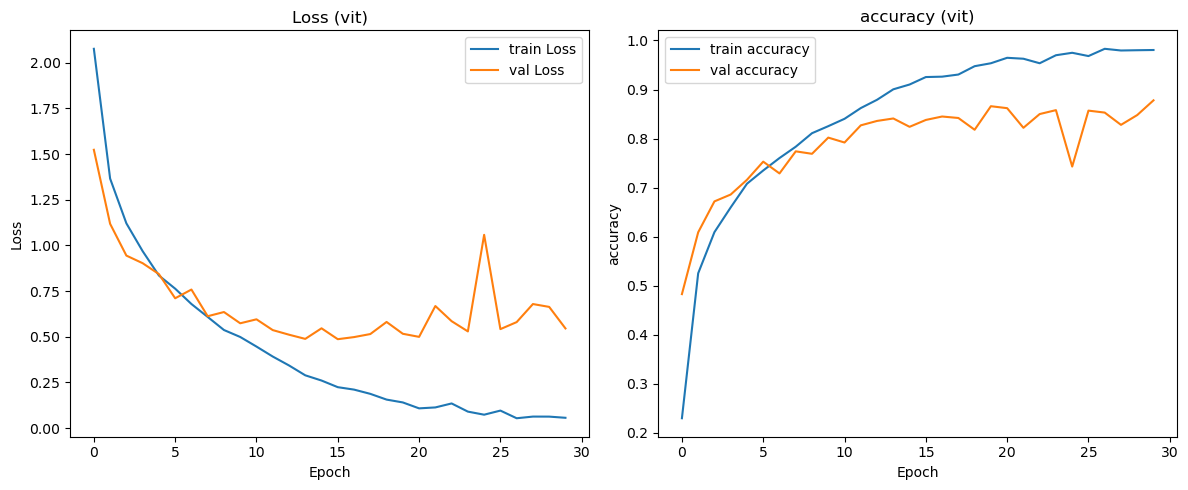

In [36]:
# loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train Loss')
plt.plot(val_losses, label='val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss (vit)")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train accuracy')
plt.plot(val_accuracies, label='val accuracy')
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("accuracy (vit)")
plt.legend()

plt.tight_layout()
plt.show()

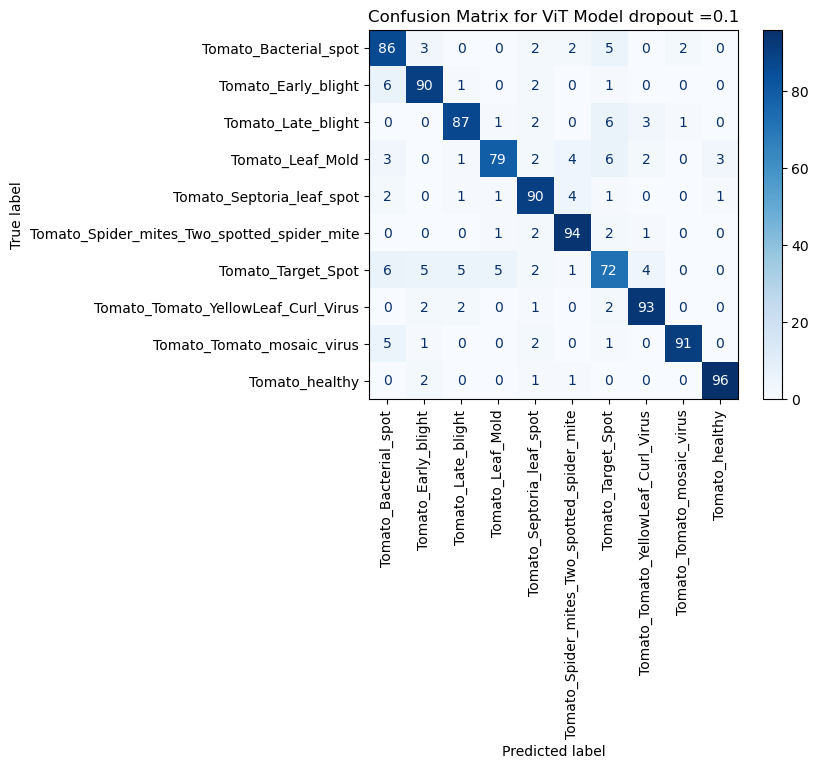

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato_Target_Spot',
    'Tomato_Tomato_YellowLeaf_Curl_Virus',
    'Tomato_Tomato_mosaic_virus',
    'Tomato_healthy'
]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=90)
# plt.figure(figsize=(12, 5))
plt.title("Confusion Matrix for ViT Model dropout =0.1")
# plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.8792
Recall:    0.8780
F1 Score:  0.8777
